# Mall Customer Segmentation

## About the dataset

The data set was obtained from kaggle: https://www.kaggle.com/datasets/abdallahwagih/mall-customers-segmentation, and conists of 200 rows belonging to a customer, and 5 features: 

- CustomerID: Integer Assigned to a customer
- Gender: Customer gender (m/f)
- Age
- Annual Income
- Spending Score

The objective of this analysis it to segment customers into groups, based on their income and their spending. Understanding these segments can help tailor marketing strategies, personalize customer experiences, and optimize business decisions to better meet the needs of different customer groups. Segmentations based on other features will also be investigated. Various cluster algorithms will be explored, namely, KMeans, Hierarchal Agglomerative Clustering (HAC), Gaussian Mixture Models (GMM), and DBSCAN.

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
def warn(*args, **kwargs):
    pass
warnings.warn = warn

# Set the file name within the dataset
file_path = "Mall_Customers.csv"

# Load the dataset into a Pandas DataFrame
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "vjchoudhary7/customer-segmentation-tutorial-in-python",
    file_path
)

### Exploratory Data Analysis

In [3]:
print(df.head())
print(df.info())
print(df.describe())
df = df.drop(columns=["CustomerID"])

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  

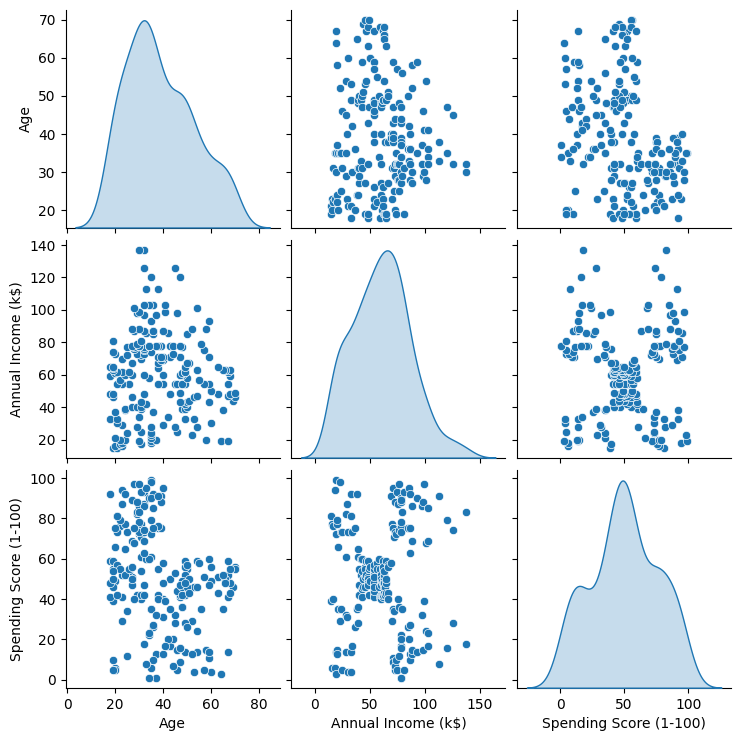

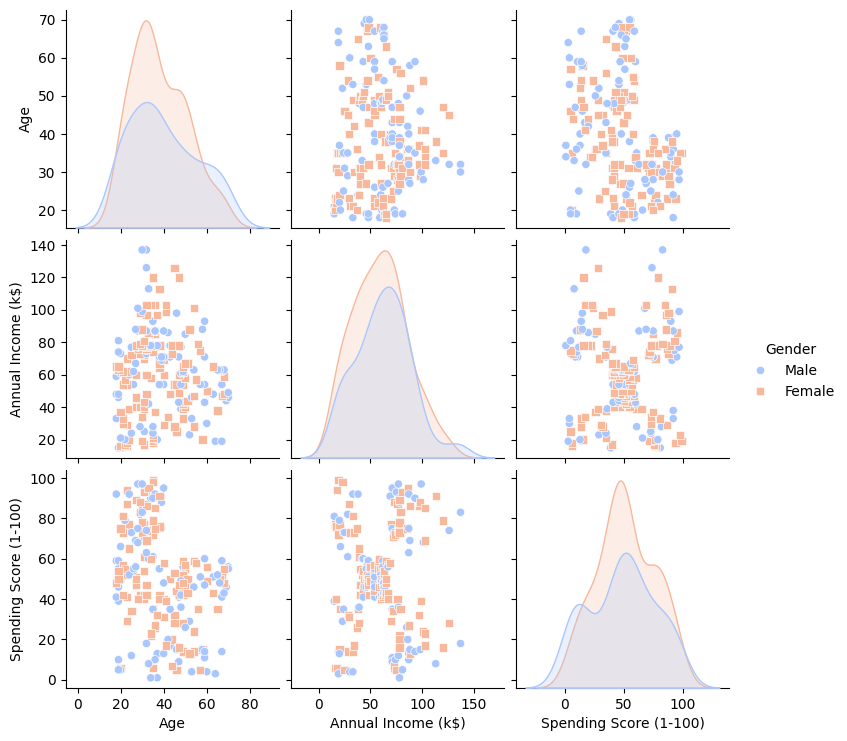

In [4]:
sns.pairplot(df, diag_kind="kde", markers=["o", "s"], palette="coolwarm")
plt.show()


sns.pairplot(df, diag_kind="kde", markers=["o", "s"], palette="coolwarm", hue="Gender")
plt.show()

Looking at the above pairplots, we can already see clearly separated data in Annual Income - Spending Score space, which possibly show 5 segmentations, which is what will be investigated. Age and spending score also seems to be fairly separated by groups of data. Overall there seems to be no apparent distinction between male/female in terms of segmentation. 


### Preprocessing

Before performign unsupervised Machine Learning tasks, the data ought to be preprocessed. First we drop the CustomerID column as this is not relevant, and not based on any physical (ordinal) feature. Then we must encode the Gender column as (0: Male; 1: Female) to obtain a fully numerical dataframe. Since the three chosen clustering algorithms are based on a distance metric, it is of utmost importance to scale the data before applying any such method. Standard Scaled data is used.

In [5]:
from sklearn.preprocessing import StandardScaler

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

scaler = StandardScaler()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print(df.head())

     Gender       Age  Annual Income (k$)  Spending Score (1-100)
0  1.128152 -1.424569           -1.738999               -0.434801
1  1.128152 -1.281035           -1.738999                1.195704
2 -0.886405 -1.352802           -1.700830               -1.715913
3 -0.886405 -1.137502           -1.700830                1.040418
4 -0.886405 -0.563369           -1.662660               -0.395980


## Clustering Algorithms

### KMeans

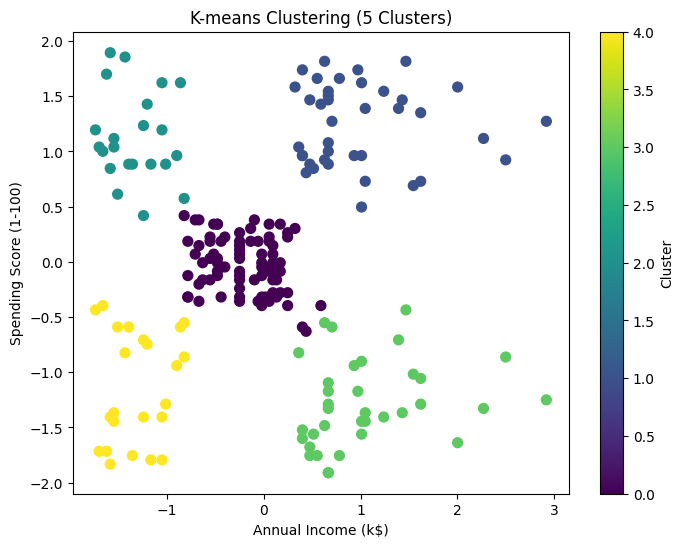

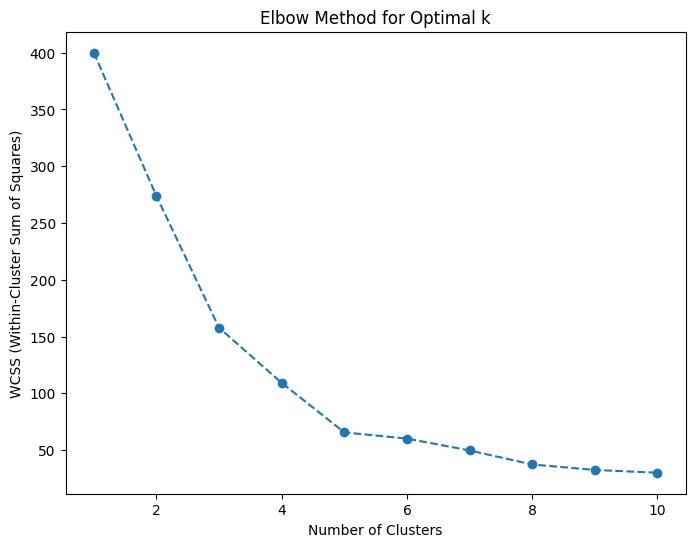

           Gender       Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                
0       -0.065660  0.277454           -0.200913               -0.026456
1        0.043390 -0.441917            0.991583                1.239503
2       -0.062268 -0.974396           -1.329545                1.132178
3        0.207212  0.162500            1.055003               -1.284439
4       -0.098100  0.456967           -1.307519               -1.136965


In [6]:
from sklearn.cluster import KMeans

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Apply KMeans clustering with 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='viridis', s=50)
plt.title('K-means Clustering (5 Clusters)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(label='Cluster')
plt.savefig('Figures/kmeans_income_score.png')
plt.show()


wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    labels = kmeans.fit_predict(X)
    wcss.append(kmeans.inertia_)


# Plot the Elbow Method graph to obtain best k
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.show()


# Get the summary statistics for each cluster
cluster_summary = df.groupby('Cluster').mean()

print(cluster_summary)

From these results we can segment the data into 5 groups. Visually this looks like the best $k$, which is also backed up by the elbow-method. All clusters look spherical with a densely backed group in the middle. We define these groups with the following labels:

- Cluster 0: "Balanced/Moderate Income and Spending"
- Cluster 1: "High-Income, High-Spending"
- Cluster 2: "Low-Income, Low-Spending"
- Cluster 3: "High-Income, Low-Spending"
- Cluster 4: "Low-Income, Moderate-Spending"


### Hierarchal Agglomerative Clustering (HAC)

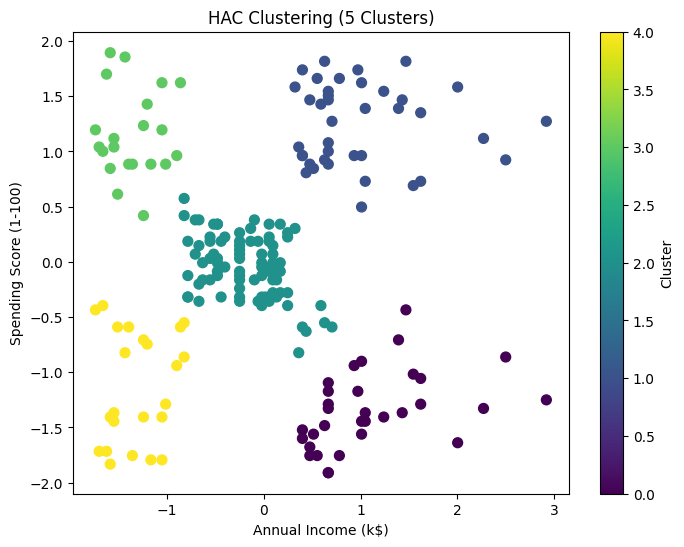

           Gender       Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                
0        0.246783  0.154298            1.101045               -1.343469
1        0.043390 -0.441917            0.991583                1.239503
2       -0.080582  0.260682           -0.181237               -0.041562
3       -0.023024 -0.970046           -1.353670                1.158731
4       -0.098100  0.456967           -1.307519               -1.136965


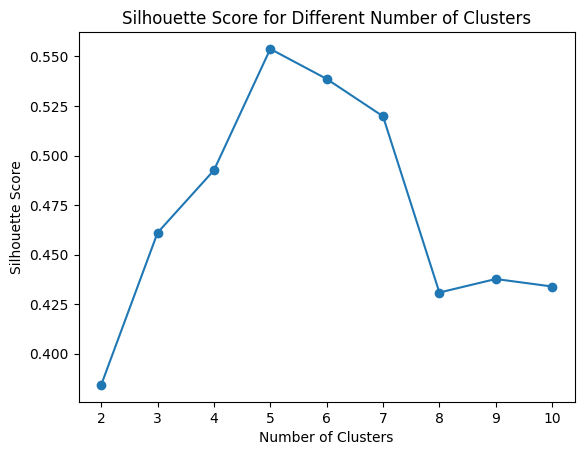

In [7]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

hac = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Cluster'] = hac.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='viridis', s=50)
plt.title('HAC Clustering (5 Clusters)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(label='Cluster')
plt.savefig('Figures/HAC_income_score.png')
plt.show()

# Get the summary statistics for each cluster
cluster_summary = df.groupby('Cluster').mean()

print(cluster_summary)


silhouette_scores = []
for k in range(2, 11): 
    hac = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = hac.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score for Different Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

With HAC we define the same 5 categories as before. The silhouette score against number of clusters, once again confirms that 5 is the best choice. Relative to KMeans the HAC clusters appear better separated but slightly imbalanced in density. 

Since both KMeans and HAC identify some points differently, it makes sense to use a soft clustering algorithm to map out the probabilities of these 'overlapping' points, belonging to a cluster. An algorithm that does this is a Gaussian Mixture Model (GMM)


### Gaussian Mixture Model (GMM)

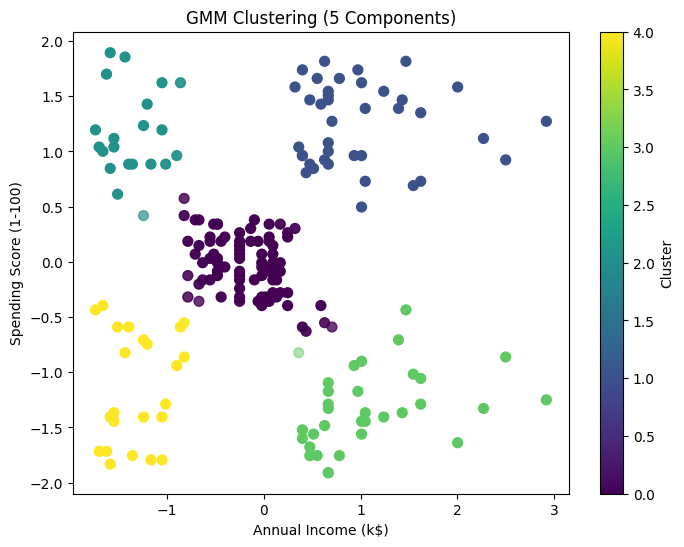

           Gender       Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                                   
0       -0.070989  0.277327           -0.187685               -0.032259   
1        0.043390 -0.441917            0.991583                1.239503   
2       -0.023024 -0.970046           -1.353670                1.158731   
3        0.212444  0.115153            1.078599               -1.327697   
4       -0.098100  0.456967           -1.307519               -1.136965   

         Cluster_Prob  
Cluster                
0            0.973185  
1            0.999965  
2            0.973496  
3            0.984038  
4            0.994309  


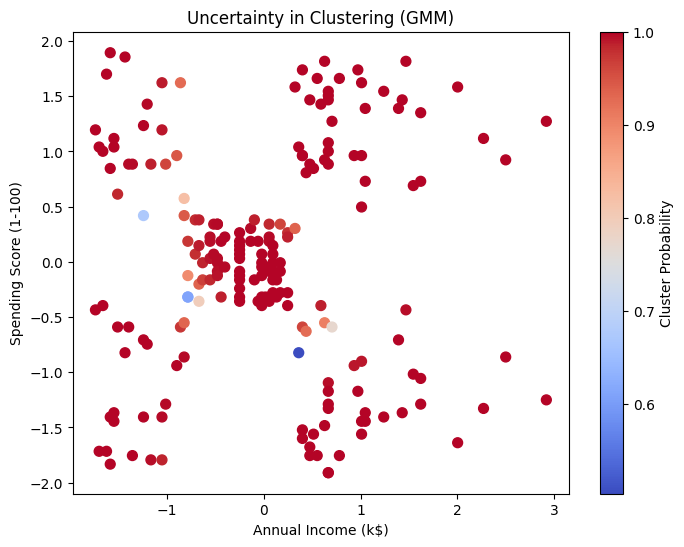

In [8]:
from sklearn.mixture import GaussianMixture

# Load your dataset (assuming df is already defined)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Fit a GMM model with 5 clusters
gmm = GaussianMixture(n_components=5, random_state=42)
df['Cluster'] = gmm.fit_predict(X)
df['Cluster_Prob'] = np.max(gmm.predict_proba(X), axis=1)  # Max probability per point

# Visualize the clusters with uncertainty
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
                      c=df['Cluster'], cmap='viridis', s=50, alpha=df['Cluster_Prob'])
plt.title('GMM Clustering (5 Components)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(label='Cluster')
plt.savefig('Figures/GMM_income_score.png')
plt.show()

# Display summary statistics for each cluster
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

# Visualizing uncertainty by plotting the probability of each point belonging to its cluster
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], 
            c=df['Cluster_Prob'], cmap='coolwarm', s=50)
plt.colorbar(label='Cluster Probability')
plt.title('Uncertainty in Clustering (GMM)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.savefig('Figures/GMM_uncertainty.png')
plt.show()

Both plots visualize the soft clustering, in which some neighboring points are identified that could belong to either cluster. This affects the middle class (Cluster 0: "Balanced/Moderate Income and Spending") the most. As observed we still see several far points (Annual Income $\sim 3$), which may be identified as outliers/noise. DBSCAN may do a good job ad indentifying these points, as well as points belonging to a cluster. Optimizing DBSCAN with its parameters $epsilon$ and $min\_samples$, will help DBSCAN to determine its own k (amount of clusters), as well as identifying the outliers.


### DBSCAN

Best eps: 0.34
Best min_samples: 3
Best Silhouette Score: 0.4710956057910501


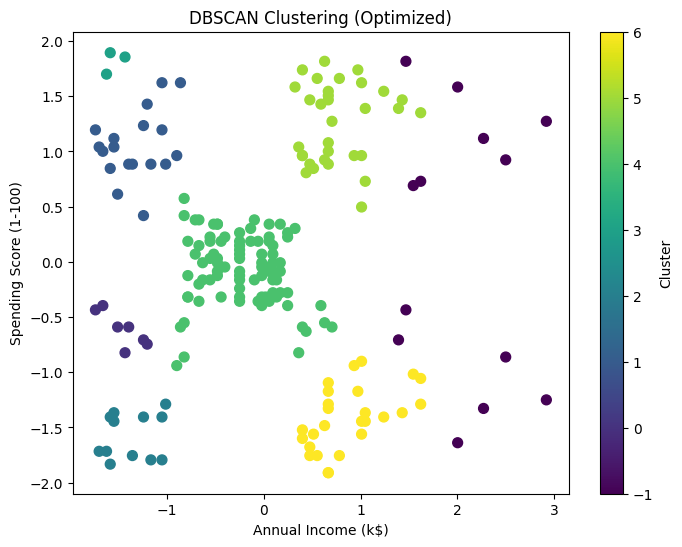

In [9]:
from sklearn.cluster import DBSCAN

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Grid search for eps and min_samples
eps_values = np.linspace(0.01, 1, 10)  # Explore different epsilon values
min_samples_values = [i for i in range(2, 11)]

best_score = -1
best_eps = None
best_min_samples = None
best_labels = None

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X)
        
        # Ignore noise points (labeled as -1) for silhouette score
        if len(set(labels)) > 1:  # If there's more than one cluster
            score = silhouette_score(X, labels)
            if score > best_score:
                best_score = score
                best_eps = eps
                best_min_samples = min_samples
                best_labels = labels

# Display best parameters
print(f"Best eps: {best_eps}")
print(f"Best min_samples: {best_min_samples}")
print(f"Best Silhouette Score: {best_score}")

# Assign the best labels to the dataframe
df['Cluster'] = best_labels

# Visualize the clustering
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='viridis', s=50)
plt.title('DBSCAN Clustering (Optimized)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(label='Cluster')
plt.savefig('Figures/DBSCAN_optimized.png')
plt.show()

After running the parameter optimized DBSCAN segmentation. We observe the following. Six clusters are formed, identifying more fine-grained structure. It also captures noise points (black, cluster -1) which might not fit well into clusters. It also handles varying densities better than K-Means and HAC. Usually DBSCAN struggles with varying densities, but since this variation is not too big, it does well with the data.

### Clustering for Age-Spending Score

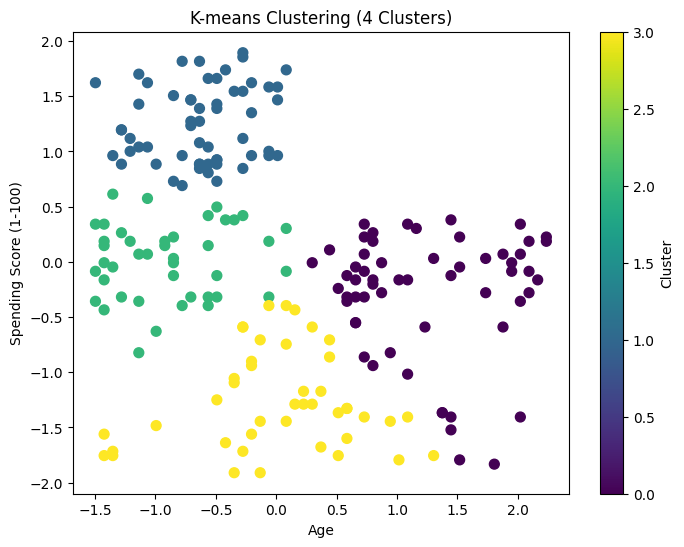

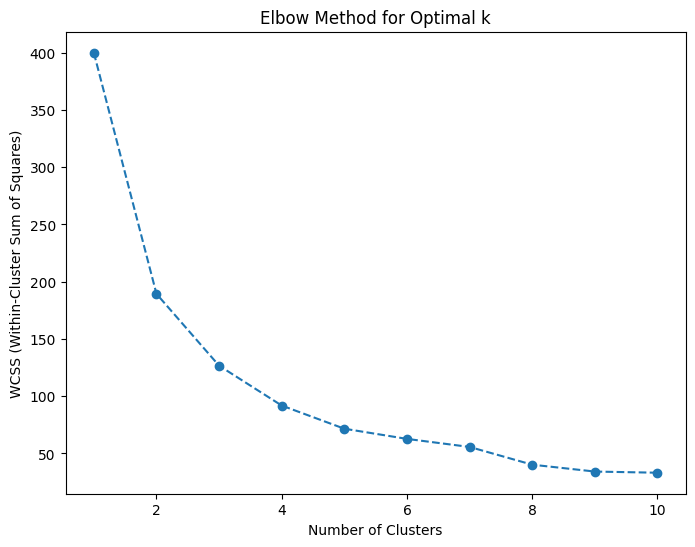

           Gender       Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                                   
0        0.120873  1.246884           -0.241178               -0.300265   
1       -0.038171 -0.622545            0.210320                1.248147   
2       -0.070989 -0.893154           -0.282199                0.011646   
3       -0.043102  0.015772            0.322150               -1.260888   

         Cluster_Prob  
Cluster                
0            0.983415  
1            0.996217  
2            0.947484  
3            0.998028  
           Gender       Age  Annual Income (k$)  Spending Score (1-100)  \
Cluster                                                                   
0       -0.041591  0.959937           -0.191290               -0.158667   
1       -0.013430 -0.639920            0.177742                1.213821   
2       -0.138141 -0.989868           -0.299466               -0.036603   
3        0.191149  0.314522   

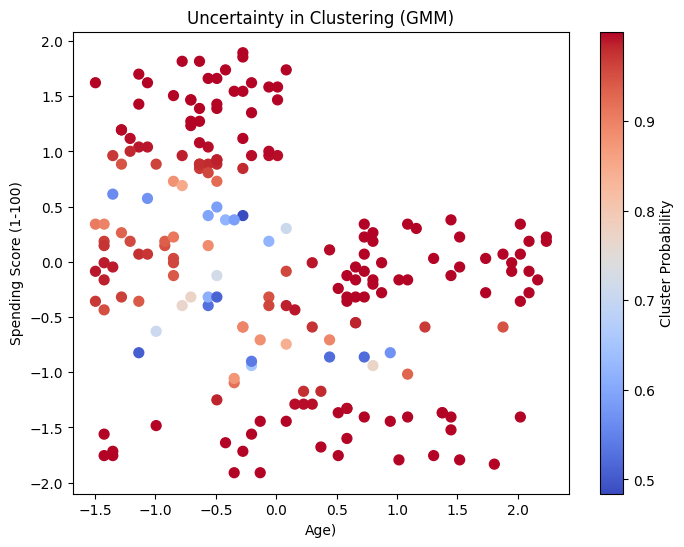

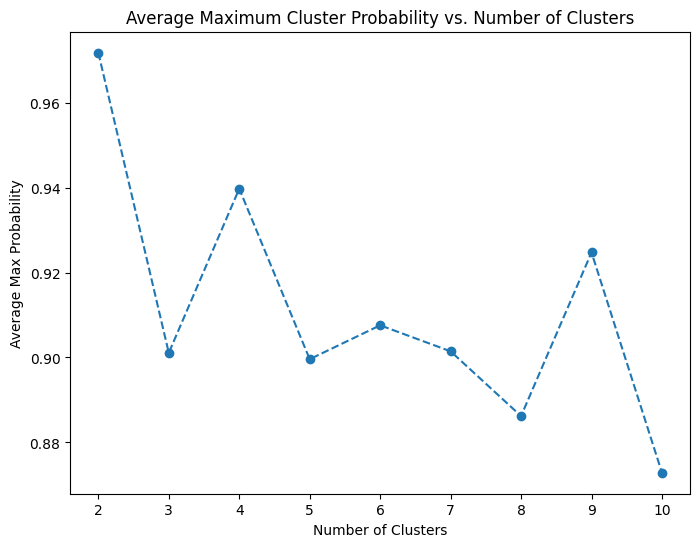

In [10]:
X = df[['Age', 'Spending Score (1-100)']]

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

# Visualize the clusters
plt.figure(figsize=(8, 6))
plt.scatter(df['Age'], df['Spending Score (1-100)'], c=df['Cluster'], cmap='viridis', s=50)
plt.title('K-means Clustering (4 Clusters)')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.colorbar(label='Cluster')
plt.savefig('Figures/KMeans_age_spending.png')
plt.show()

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.savefig('Figures/Elbow_KMeans_age_spending.png')
plt.show()


# Get the summary statistics for each cluster
cluster_summary = df.groupby('Cluster').mean()

print(cluster_summary)




# Fit a GMM model with 4 clusters
gmm = GaussianMixture(n_components=4, random_state=42)
df['Cluster'] = gmm.fit_predict(X)
df['Cluster_Prob'] = np.max(gmm.predict_proba(X), axis=1)  # Max probability per point

# Display summary statistics for each cluster
cluster_summary = df.groupby('Cluster').mean()
print(cluster_summary)

# Visualizing uncertainty by plotting the probability of each point belonging to its cluster
plt.figure(figsize=(8, 6))
plt.scatter(df['Age'], df['Spending Score (1-100)'], 
            c=df['Cluster_Prob'], cmap='coolwarm', s=50)
plt.colorbar(label='Cluster Probability')
plt.title('Uncertainty in Clustering (GMM)')
plt.xlabel('Age)')
plt.ylabel('Spending Score (1-100)')
plt.savefig('Figures/GMM_uncertainty_age_spending.png')
plt.show()


avg_probs = []

for n in range(2, 11):
    gmm = GaussianMixture(n_components=n, random_state=42)
    df['Cluster'] = gmm.fit_predict(X)
    df['Cluster_Prob'] = np.max(gmm.predict_proba(X), axis=1)
    avg_probs.append(np.mean(df['Cluster_Prob']))

# Plot the average cluster probabilities
plt.figure(figsize=(8, 6))
plt.plot(range(2, 11), avg_probs, marker='o', linestyle='--')
plt.title('Average Maximum Cluster Probability vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Average Max Probability')
plt.savefig('Figures/GMM_certainty_nclusters.png')
plt.show()

Visually, it is difficult to identify clear grouping in the data. The fact that the elbow curve is gradual suggests there is no strong intra-cluster similarity or clear separations in this feature space. GMM Soft clustering shows a large amount of overlapping points for 5 clusters. To investigate this further the average probability over all clusters was plotted against the amount of clusters, to demonstrate how certain GMM identifies its clusters based on varying number of clusters. No clear global optimum can be seen although 4 may do the best job locally. Which is why 4 was picked for demonstration purposes. To further invesigate a possible relationship in this feature space we could do 3D cluster analysis (Age, Income, Spending Score)

## Key Insights

If the goal is to segment each customer into a group to personalize their experience, DBSCAN may not be useful as it leaves unsegmented outliers. Using the other clustering algorithms we find 5 clear segments 

- Cluster 0: "Balanced/Moderate Income and Spending"
- Cluster 1: "High-Income, High-Spending"
- Cluster 2: "Low-Income, Low-Spending"
- Cluster 3: "High-Income, Low-Spending"
- Cluster 4: "Low-Income, Moderate-Spending"


KMeans as well as HAC both segment the same groups differently, which is why GMM's soft clustering may be the best option to identify overlapping points. The latter may be the best suitable for business decisions.


No clear segmentation could be found with Age and Spending Score. One could imagine that age is in fact an important factor in consumer behavior, which may be useful for segmentation. However the data in this data set does not allow for this. A more complete dataset may include the type of item which was purchased which may give more insight into possible age segementation.


## Future Prospect
- Incorporate additional data (e.g., purchase history, frequency of visits, product categories preferred) to improve segmentation.
- Introduce derived features such as income-to-spending ratio to better capture spending behavior.
